# [Protected secrets in Kubernetes with CSI](https://developer.hashicorp.com/vault/docs/deploy/kubernetes/vso/csi)

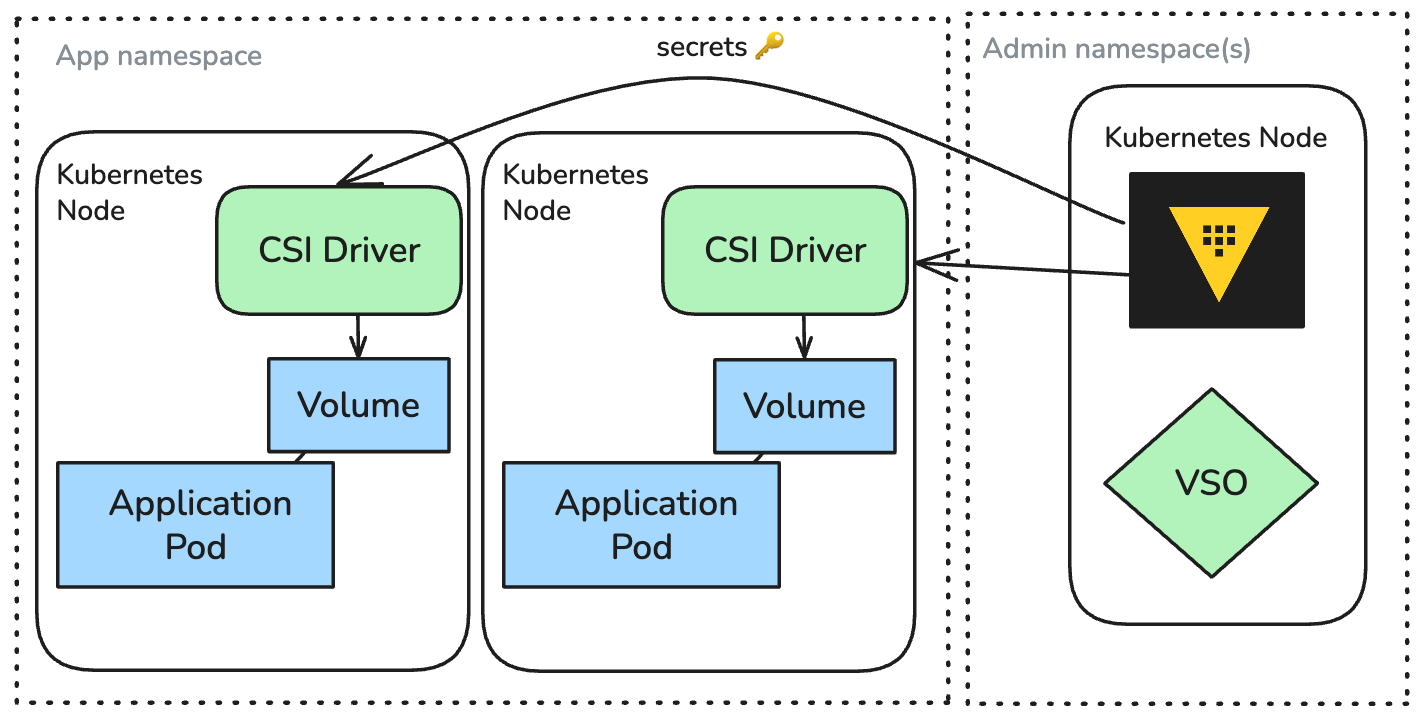

## Set environment variables for Vault and Kubernetes
These variables are used throughout the notebook for configuration.

In [ ]:
%env WORKDIR=/tmp/vault
%env VAULT_K8S_NAMESPACE=vault
%env VAULT_HELM_RELEASE_NAME=vault
%env VAULT_SERVICE_NAME=vault-internal 
%env K8S_CLUSTER_NAME=cluster.local 

## Load Vault credentials from environment
This cell loads Vault token, address, and CA cert from the .env file.

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv("/tmp/vault/config.env")

VAULT_TOKEN = os.getenv('VAULT_TOKEN')
VAULT_ADDR = os.getenv('VAULT_ADDR')
VAULT_CACERT = os.getenv('VAULT_CACERT')


## Enable CSI in Vault Secrets Operator
This cell upgrades the VSO Helm release to enable CSI support.

In [ ]:
%%bash
helm upgrade --namespace vault-secrets-operator --set "csi.enabled=true" vault-secrets-operator hashicorp/vault-secrets-operator

## Show recent events in VSO namespace
Useful for debugging deployment and CSI issues.

In [ ]:
! kubectl get events -n vault-secrets-operator | tail -20

## List VSO pods
Check the status of Vault Secrets Operator pods.

In [ ]:
! kubectl get pods -n vault-secrets-operator

## Create Vault policy for CSI driver
Defines permissions for reading secrets and AppRole credentials.

In [ ]:
%%bash
vault policy write csi-driver-policy - <<EOF
path "example-kv/password" {
    capabilities = ["read"]
}

path "example-kv-v2/data/api-key" {
    capabilities = ["read"]
}

path "sys/license/status" {
    capabilities = ["read"]
}

path "auth/approle/role/my-app/secret-id" {
    capabilities = ["update"]
}

path "auth/approle/role/my-app/role-id" {
    capabilities = ["read"]
}
EOF

## Create secrets and AppRole in Vault
Sets up KV secrets and AppRole for CSI access.

In [ ]:
%%bash
# Create Secret and AppRole in Vault
vault secrets enable -path=example-kv kv
vault kv put example-kv/password value="s3cr3tP@ssw0rd"

vault secrets enable -path=example-kv-v2 kv-v2
vault kv put example-kv-v2/api-key value="my-api-key-123456"

vault auth enable approle


## Create AppRole for application
AppRole is used by CSI to authenticate and retrieve secrets.

In [ ]:
%%bash
vault write auth/approle/role/my-app token_policies="csi-driver-policy" token_ttl=1h token_max_ttl=4h
vault read auth/approle/role/my-app/role-id
vault write -f auth/approle/role/my-app/secret-id

## Create Kubernetes role for Vault authentication
Defines how the application service account can authenticate to Vault.

In [ ]:
%%bash
vault write auth/kubernetes/role/example-auth-role                        \
    bound_service_account_names=psecret                                   \
    bound_service_account_namespaces=psecret,vault-secrets-operator       \
    token_period=120                                                      \
    token_policies=csi-driver-policy                                      \
    audience=vault


## Create namespace and service account for the app
Sets up Kubernetes resources needed for the demo.

In [ ]:
%%bash
kubectl create ns psecret
kubectl create sa psecret -n psecret

## Create service account in VSO namespace
Required for Vault authentication and CSI access.

In [ ]:
! kubectl create sa psecret -n vault-secrets-operator

## Create VaultAuth and VaultAuthGlobal resources
Configure Vault authentication for the application and CSI driver.

In [ ]:
%%bash
cat > ${WORKDIR}/vaultauth2_crd.yaml <<EOF
apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultAuth
metadata:
 name: example2
 namespace: vault-secrets-operator
spec:
 vaultAuthGlobalRef:
   name: default

---

apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultAuthGlobal
metadata:
 name: default
 namespace: vault-secrets-operator
spec:
 vaultConnectionRef: example
 defaultAuthMethod: kubernetes
 kubernetes:
   audiences:
     - vault
   mount: kubernetes
   role: example-auth-role
   serviceAccount: psecret
   tokenExpirationSeconds: 600

EOF

kubectl apply -f ${WORKDIR}/vaultauth2_crd.yaml

## Describe VaultAuth resource
Check status and details of VaultAuth configuration.

In [ ]:
! kubectl describe VaultAuth example2 -n vault-secrets-operator

## Create CSISecrets resource
Defines which secrets are exposed to the application via CSI.

In [ ]:
%%bash
cat > ${WORKDIR}/csisecrets_crd.yaml <<EOF
apiVersion: secrets.hashicorp.com/v1beta1
kind: CSISecrets
metadata:
  name: my-app-secrets
  namespace: vault-secrets-operator
spec:
  vaultAuthRef:
    name: example2
  secrets:
    vaultStaticSecrets:
      - mount: example-kv
        path: password
        type: kv-v1
      - mount: example-kv-v2
        path: api-key
        type: kv-v2
        version: 1 # The version of the KV secret -- if not specified, defaults to the latest version
    vaultAppRoleSecretIDs:
      - role: my-app
        mount: approle
        wrapTTL: "30m"
        ttl: "1h"
        numUses: 2
  accessControl:
    matchPolicy: all
    serviceAccountPattern: "^psecret$"
    namespacePatterns:
      - "^psecret$"
    podNamePatterns:
      - "^my-app-"


EOF
kubectl apply -f ${WORKDIR}/csisecrets_crd.yaml

## Describe CSISecrets resource
Check status and details of the CSISecrets configuration.

In [ ]:
! kubectl describe CSISecrets -n vault-secrets-operator my-app-secrets 

## Create RBAC for CSI driver
Grants the CSI node service account permission to read CSISecrets resources.

In [ ]:
%%bash
# Create ClusterRole to read CSISecrets
cat > ${WORKDIR}/csi-rbac.yaml <<EOF
---
apiVersion: rbac.authorization.k8s.io/v1
kind: ClusterRole
metadata:
  name: vso-csi-secrets-reader
rules:
- apiGroups: ["secrets.hashicorp.com"]
  resources: ["csisecrets"]
  verbs: ["get", "list", "watch"]

---
apiVersion: rbac.authorization.k8s.io/v1
kind: ClusterRoleBinding
metadata:
  name: vso-csi-secrets-reader
roleRef:
  apiGroup: rbac.authorization.k8s.io
  kind: ClusterRole
  name: vso-csi-secrets-reader
subjects:
- kind: ServiceAccount
  name: vault-secrets-operator-csi-node
  namespace: vault-secrets-operator

EOF

kubectl apply -f ${WORKDIR}/csi-rbac.yaml

# Create Application and mount secrets

In [ ]:
%%bash

cat > ${WORKDIR}/my_app_deployment.yaml <<EOF
apiVersion: apps/v1
kind: Deployment
metadata:
  name: my-app
  namespace: psecret
  labels:
    app.kubernetes.io/component: my-app
spec:
  selector:
    matchLabels:
      app.kubernetes.io/component: my-app
  replicas: 2
  template:
    metadata:
      labels:
        app.kubernetes.io/component: my-app
    spec:
      serviceAccountName: psecret
      containers:
      - name: app
        image: nginx:latest
        volumeMounts:
        - name: csi-secrets
          mountPath: /var/run/csi-secrets
      - name: sidecar
        image: redis:latest
        volumeMounts:
        - name: csi-secrets
          mountPath: /var/run/csi-secrets
      volumes:
      - name: csi-secrets
        csi:
          driver: csi.vso.hashicorp.com
          volumeAttributes:
            csiSecretsName: my-app-secrets
            csiSecretsNamespace: vault-secrets-operator

EOF
kubectl apply -f ${WORKDIR}/my_app_deployment.yaml



In [ ]:
! kubectl get pods -n psecret

In [ ]:
%%bash
# REad secrets via exec
export POD=$(kubectl get pods -n psecret -l app.kubernetes.io/component=my-app -o jsonpath="{.items[0].metadata.name}")
kubectl exec -i -t $POD -n psecret -- ls /var/run/csi-secrets/